# Import Libraries📚

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, LSTM, Dropout
from keras.models import Sequential

import os

np.random.seed(14)

# Data Preprocessing

In [27]:
data = pd.read_csv('Data/Stocks/ufi.us.txt', delimiter=',')
data=data[['Date','Open','High','Low','Volume','Close']]
data.head()

,Date,Open,High,Low,Volume,Close
0,2005-02-25,12.09,13.20,12.06,318399,13.08
1,2005-02-28,13.05,13.32,12.27,33966,12.57
2,2005-03-01,12.60,12.78,12.09,42066,12.66
3,2005-03-02,12.90,13.62,12.75,81666,13.50
4,2005-03-03,13.65,13.65,12.60,100299,12.78


In [28]:
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')
data = data.set_index('Date')
data.head()

,Open,High,Low,Volume,Close
Date,,,,,
2005-02-25,12.09,13.20,12.06,318399,13.08
2005-02-28,13.05,13.32,12.27,33966,12.57
2005-03-01,12.60,12.78,12.09,42066,12.66
2005-03-02,12.90,13.62,12.75,81666,13.50
2005-03-03,13.65,13.65,12.60,100299,12.78


In [29]:
data.isnull().mean()

Open      0.0
High      0.0
Low       0.0
Volume    0.0
Close     0.0
dtype: float64

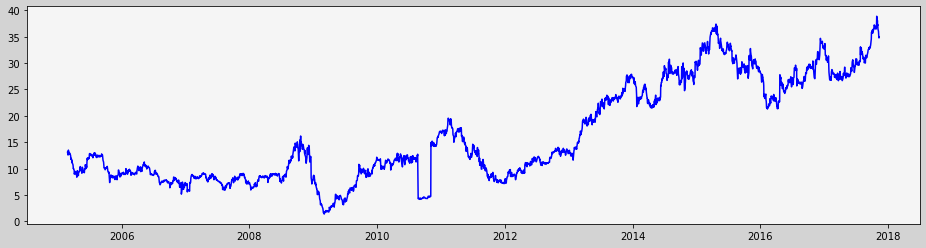

In [30]:
plt.figure(figsize=(16,4), facecolor='lightgrey')
ax = plt.axes()
ax.set_facecolor('whitesmoke')
plt.plot(data['Close'], color='blue')
plt.show()

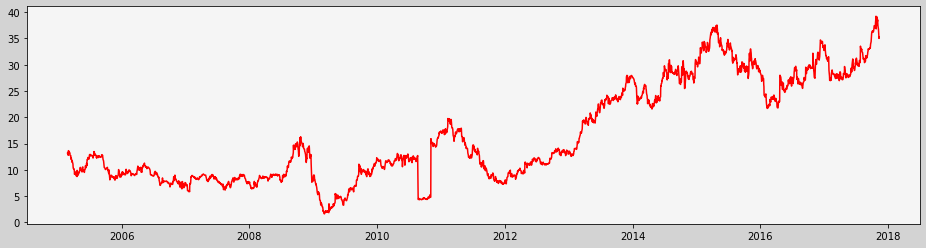

In [31]:
plt.figure(figsize=(16,4), facecolor='lightgrey')
ax = plt.axes()
ax.set_facecolor('whitesmoke')
plt.plot(data['High'], color='red')

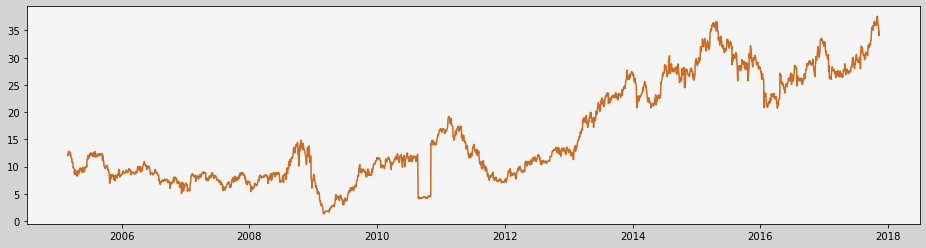

In [32]:
plt.figure(figsize=(16,4), facecolor='lightgrey')
ax = plt.axes()
ax.set_facecolor('whitesmoke')
plt.plot(data['Low'], color='chocolate')

In [33]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    dff = pd.DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(dff.shift(-i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(dff.shift(-i))
        if i==0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1)) for j in range(n_vars)]      
        agg = pd.concat(cols, axis=1)
        agg.columns = names
        if dropnan:
            agg.dropna(inplace=True)
        return agg

In [34]:
data_value = data.values
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data_value)
data_reframed = series_to_supervised(data_scaled)

In [35]:
pd.set_option('display.max_columns', None)
data_reframed.head()

,var1(t-1),var2(t-1),var3(t-1),var4(t-1),var5(t-1),var1(t),var2(t),var3(t),var4(t),var5(t)
0,0.309987,0.311253,0.301694,0.011049,0.297997,0.284421,0.308061,0.295909,0.104961,0.311615
1,0.298003,0.296887,0.296735,0.013724,0.300401,0.309987,0.311253,0.301694,0.011049,0.297997
2,0.305992,0.319234,0.314919,0.026799,0.322830,0.298003,0.296887,0.296735,0.013724,0.300401
3,0.325965,0.320032,0.310787,0.032951,0.303605,0.305992,0.319234,0.314919,0.026799,0.322830
4,0.305992,0.309657,0.309133,0.011897,0.304406,0.325965,0.320032,0.310787,0.032951,0.303605


In [36]:
data_reframed.drop(["var1(t)", "var2(t)", "var3(t)", "var4(t)"], inplace=True, axis=1)
data_reframed.head()

,var1(t-1),var2(t-1),var3(t-1),var4(t-1),var5(t-1),var5(t)
0,0.309987,0.311253,0.301694,0.011049,0.297997,0.311615
1,0.298003,0.296887,0.296735,0.013724,0.300401,0.297997
2,0.305992,0.319234,0.314919,0.026799,0.322830,0.300401
3,0.325965,0.320032,0.310787,0.032951,0.303605,0.322830
4,0.305992,0.309657,0.309133,0.011897,0.304406,0.303605


In [37]:
num = int(data_reframed.shape[0]*0.8)
value = data_reframed.values
train = value[:num, :]
test = value[num:, :]

In [38]:
train_x, train_y = train[:, :-1], train[:, -1]
test_x, test_y = test[:, :-1], test[:, -1]
# reshape input to be 3D
train_x = train_x.reshape((train_x.shape[0], 1, train_x.shape[1]))
test_x = test_x.reshape((test_x.shape[0], 1, test_x.shape[1]))
print(train_x.shape, test_x.shape )
print(train_y.shape, test_y.shape )

(2560, 1, 5) (640, 1, 5)
(2560,) (640,)


# LSTM Model

In [39]:
Model = Sequential()
Model.add(LSTM(150, input_shape=(train_x.shape[1], train_x.shape[2]), return_sequences=True))
Model.add(LSTM(40, return_sequences=True))
Model.add(Dropout(0.2))
Model.add(LSTM(10))
Model.add(Dense(1))
Model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 1, 150)            93600     
                                                                 
 lstm_4 (LSTM)               (None, 1, 40)             30560     
                                                                 
 dropout_1 (Dropout)         (None, 1, 40)             0         
                                                                 
 lstm_5 (LSTM)               (None, 10)                2040      
                                                                 
 dense_1 (Dense)             (None, 1)                 11        
                                                                 
Total params: 126,211
Trainable params: 126,211
Non-trainable params: 0
_________________________________________________________________


Epoch 1/15
40/40 [==============================] - 6s 41ms/step - loss: 0.0881 - val_loss: 0.1032
Epoch 2/15
40/40 [==============================] - 0s 6ms/step - loss: 0.0098 - val_loss: 0.0059
Epoch 3/15
40/40 [==============================] - 0s 6ms/step - loss: 0.0023 - val_loss: 2.4094e-04
Epoch 4/15
40/40 [==============================] - 0s 6ms/step - loss: 0.0013 - val_loss: 5.7878e-04
Epoch 5/15
40/40 [==============================] - 0s 6ms/step - loss: 0.0012 - val_loss: 1.8922e-04
Epoch 6/15
40/40 [==============================] - 0s 6ms/step - loss: 0.0011 - val_loss: 2.5014e-04
Epoch 7/15
40/40 [==============================] - 0s 6ms/step - loss: 8.9962e-04 - val_loss: 1.6751e-04
Epoch 8/15
40/40 [==============================] - 0s 6ms/step - loss: 8.3834e-04 - val_loss: 2.2312e-04
Epoch 9/15
40/40 [==============================] - 0s 6ms/step - loss: 7.6223e-04 - val_loss: 3.3587e-04
Epoch 10/15
40/40 [==============================] - 0s 6ms/step - loss: 7.19

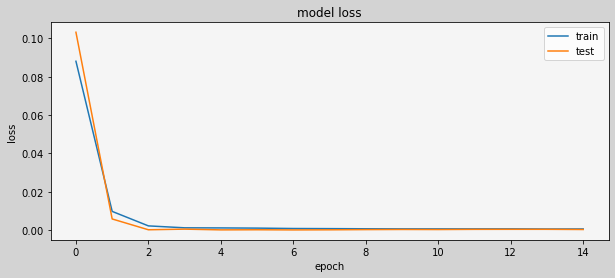

In [40]:
Model.compile(loss='mean_squared_error', optimizer='adam')
history = Model.fit(train_x, train_y, epochs=15, batch_size=64, validation_data=(test_x, test_y))
plt.figure(figsize=(10,4), facecolor='lightgrey')
ax = plt.axes()
ax.set_facecolor('whitesmoke')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [41]:
yPredict = Model.predict(test_x)

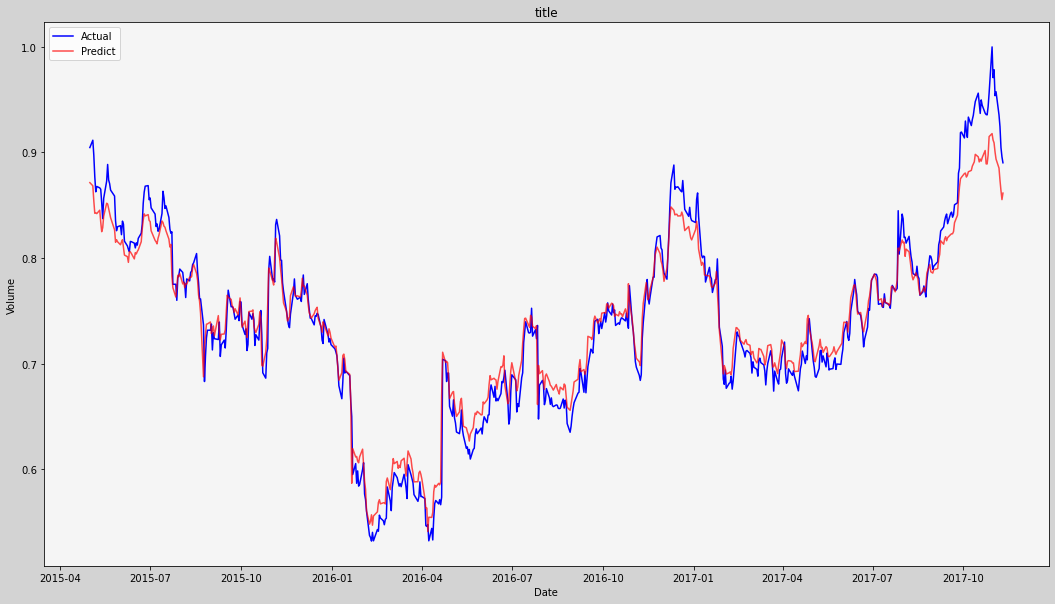

In [42]:
plt.figure(figsize=(18,10), facecolor='lightgrey')
ax = plt.axes()
ax.set_facecolor('whitesmoke')
plt.plot(data.index[-640:], test_y, color='blue',label='Actual')
plt.plot(data.index[-640:], yPredict, alpha=0.7, color='red',label='Predict')
plt.title('title')
plt.xlabel('Date')
plt.ylabel('V')
plt.legend()
plt.show()